<a href="https://colab.research.google.com/github/NoahSlaa/bioinfomatician/blob/main/blood%20pressure%20_analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
uploded=files.upload()

Saving test (1).csv to test (1).csv


,BP,Max HR,Age
count,193405.000000,193405.000000,193405.000000
mean,130.530116,150.693726,54.595983
std,14.949793,19.637739,8.183965
min,94.000000,71.000000,29.000000
25%,120.000000,140.000000,49.000000
50%,130.000000,154.000000,55.000000
75%,140.000000,163.000000,60.000000
max,200.000000,202.000000,77.000000


,BP,Max HR,Age
count,76595.000000,76595.000000,76595.000000
mean,130.618147,158.061153,53.058672
std,15.153572,16.749405,8.332408
min,94.000000,71.000000,29.000000
25%,120.000000,150.000000,46.000000
50%,130.000000,161.000000,53.000000
75%,140.000000,171.000000,59.000000
max,200.000000,202.000000,77.000000


We are going to visualize our sorted data in countplot boxplots and stratified scatter plot ,to show distribution  of blood pressure in different ages groups 
This step is very important in our analysis because it going to give actual  statitical picture and propose what are biological or environmental factors that contribute for.


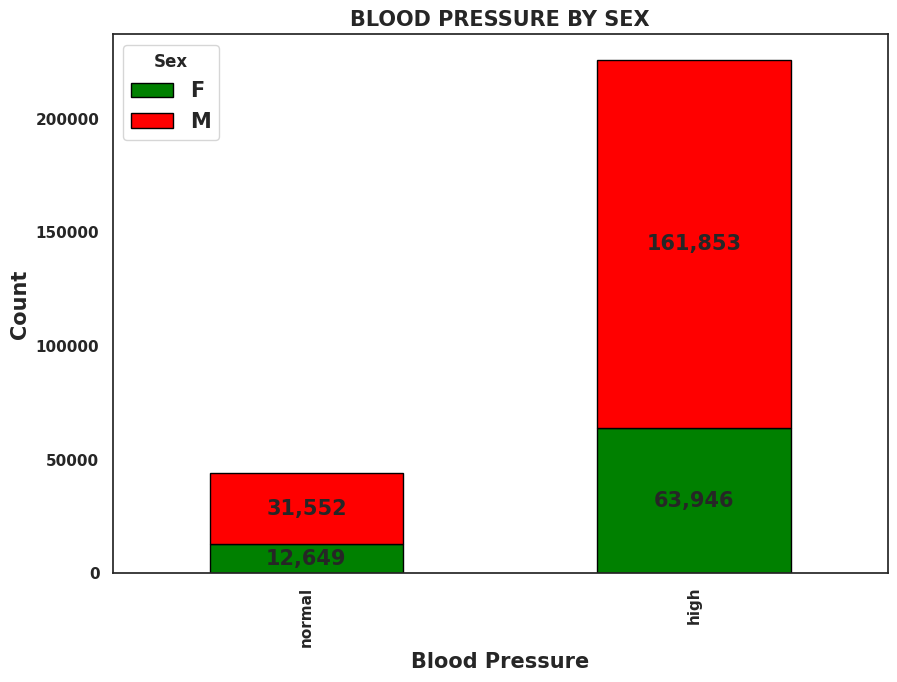

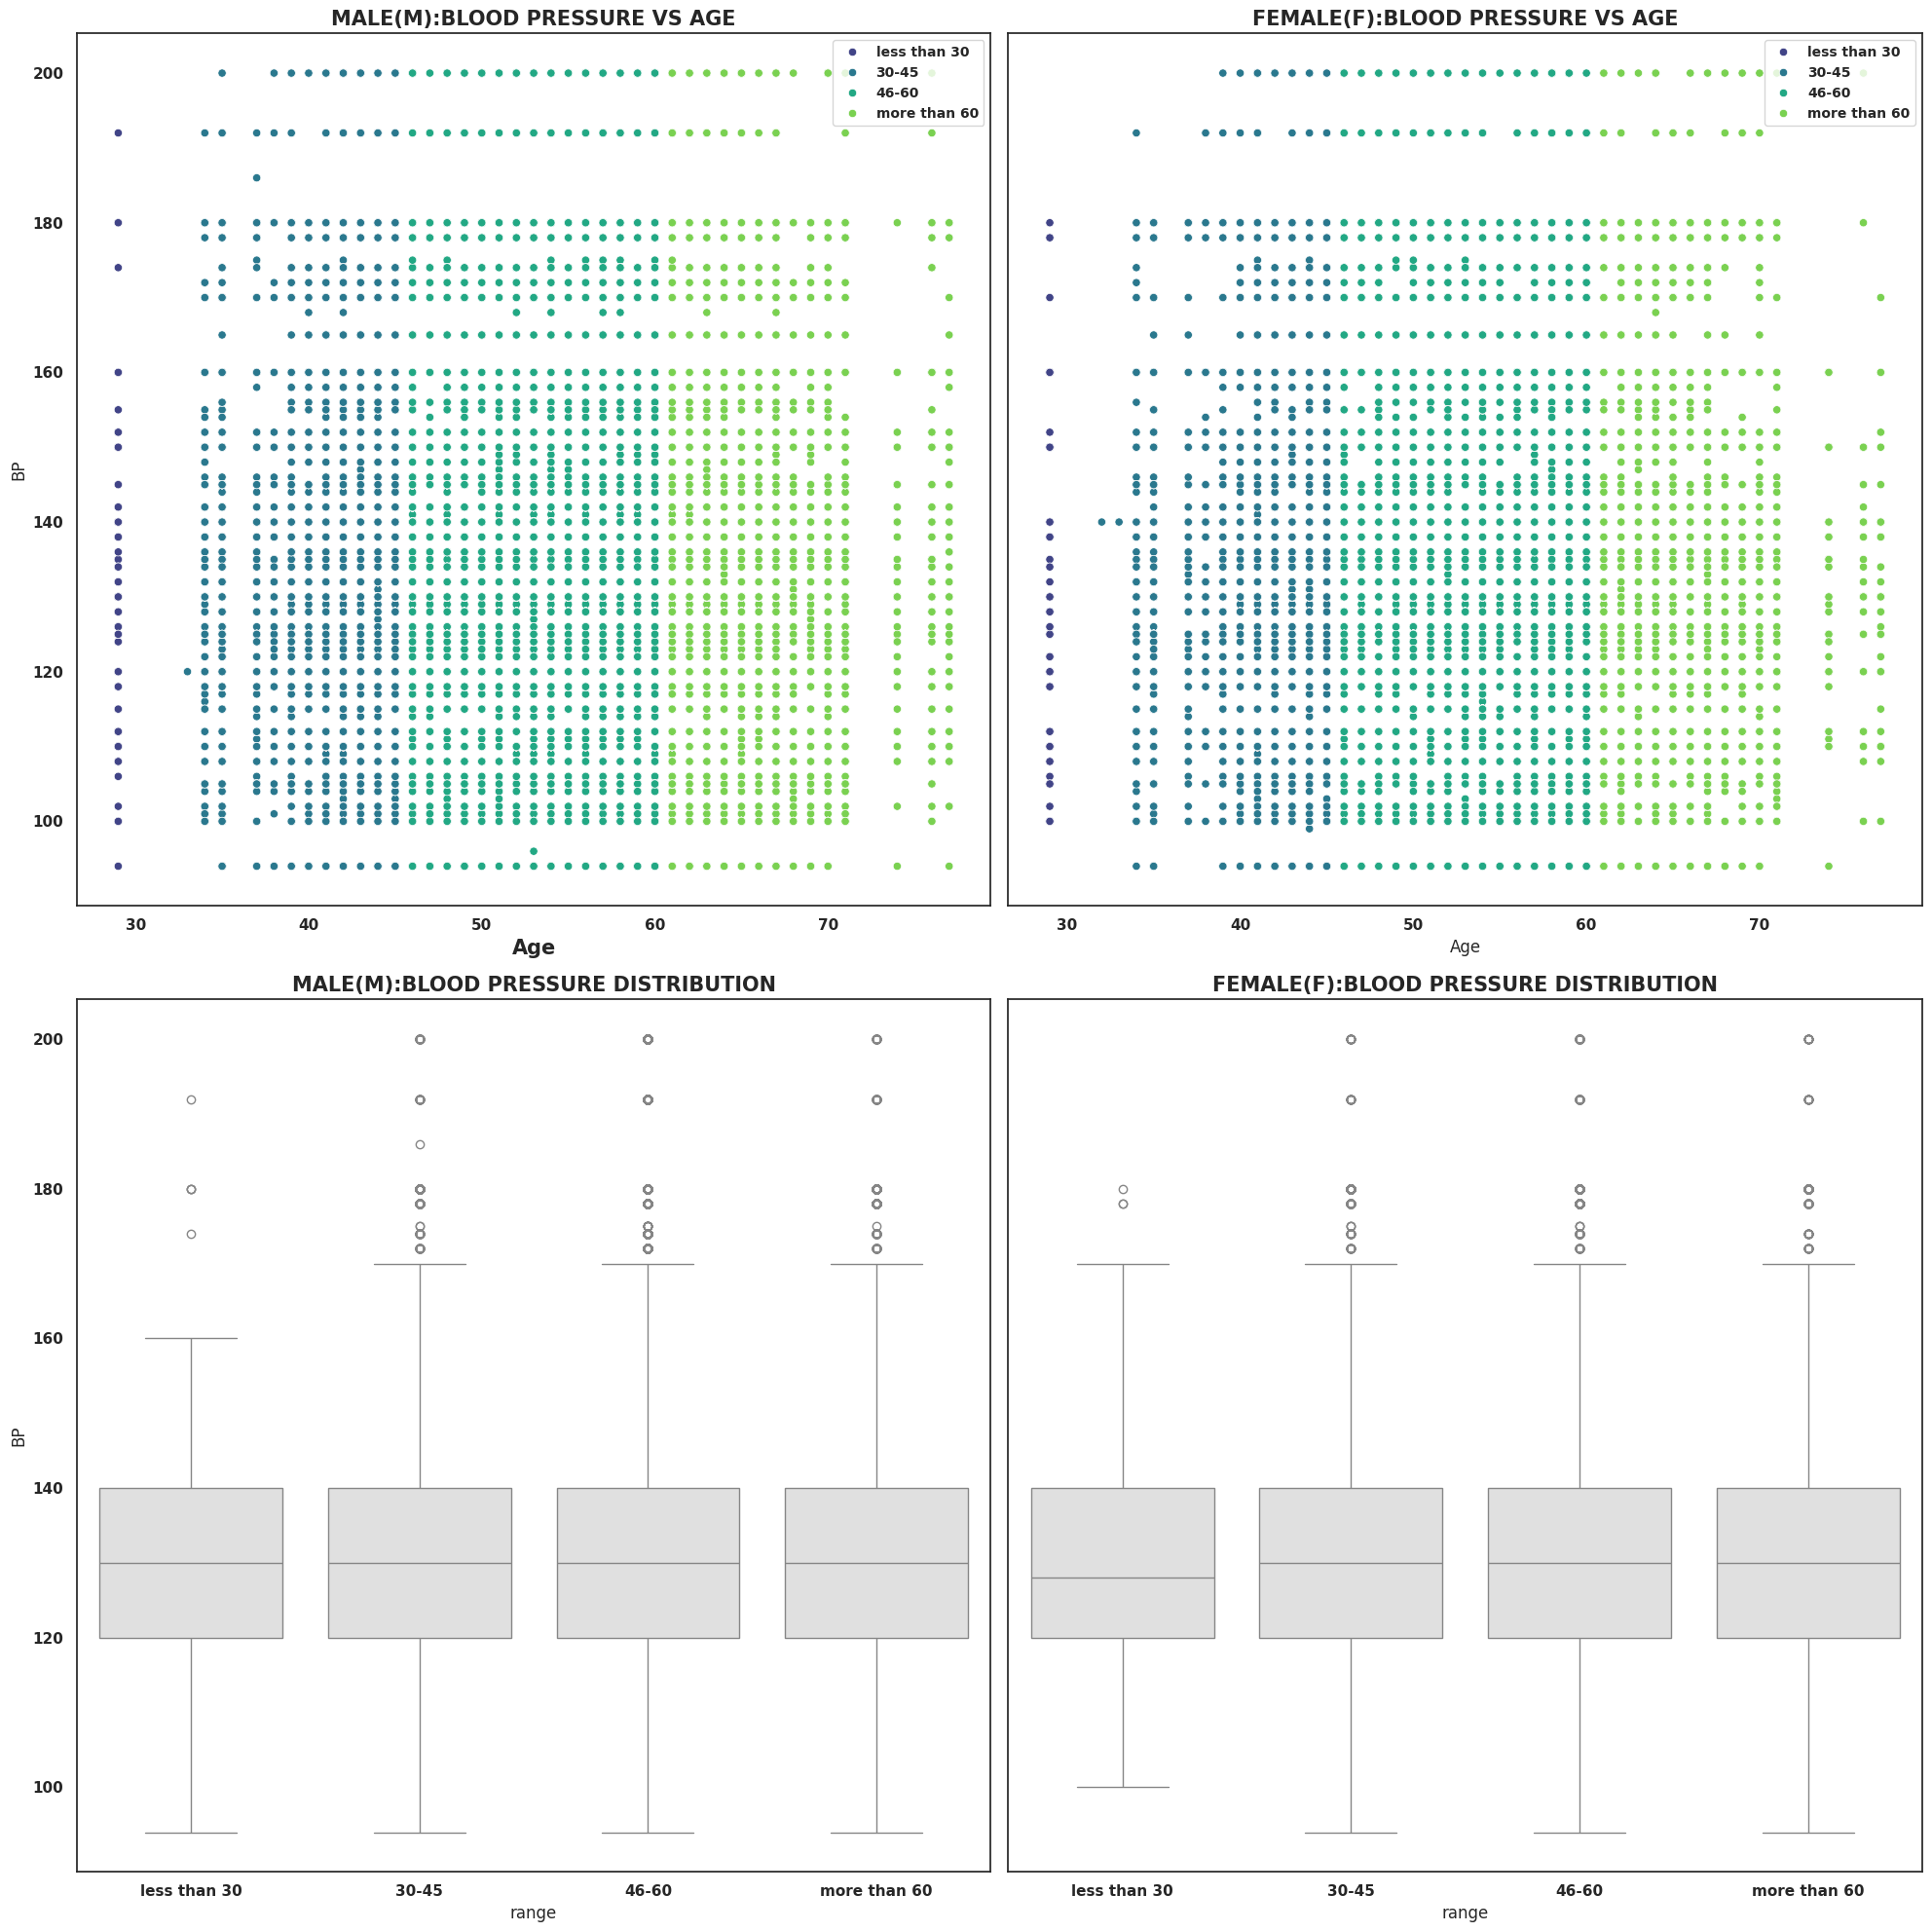

In [48]:
from numpy._core.defchararray import title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Data processing and Filtering
df=pd.read_csv("/content/test (1).csv")

data=df[["Sex","BP","Max HR","Age"]].reset_index(drop=True)
data["Sex"]=df["Sex"].replace({1: "M",0: "F"})
x=data[data["Sex"]=="M"]
y=data[data["Sex"]=="F"]
display(x.describe())
display(y.describe())

#Data visualization for Blood pressure
sns.set_theme(style="white",context="notebook")
plt.rcParams["font.weight"]="bold"
bins=[0,89,119,300]
bp_labels=["low","normal","high"]
data["BP_category"]=pd.cut(data["BP"],bins=bins,labels=bp_labels)
pivot=pd.crosstab(data["BP_category"],data["Sex"])
ax=pivot.plot(kind="bar",stacked=True,figsize=(10,7),color=["green","red"],edgecolor="black",linewidth=1)

plt.title("BLOOD PRESSURE BY SEX",fontsize=15,weight="bold")
plt.xlabel("Blood Pressure",fontsize=15,weight="bold")
plt.ylabel("Count",fontsize=15,weight="bold")
plt.legend(title="Sex",fontsize=15)
for p in  ax.patches:
  width,height=p.get_width(),p.get_height()
  x_pos,y_pos=p.get_xy()
  if height > 0:
    ax.text(x_pos +width/2,
            y_pos +height/2,f'{int(height):,}',
            horizontalalignment="center",
            verticalalignment="center",weight="bold",fontsize=15)



ages=[0,30,45,60,100]
labels=["less than 30","30-45","46-60","more than 60"]
data["range"]=pd.cut(data["Age"],bins=ages,labels=labels)
fig,axes=plt.subplots(2,2,figsize=(20,20),sharey=True)

sns.scatterplot(data=x,x="Age",y="BP",hue=data["range"],ax=axes[0,0],palette="viridis",alpha=1)
sns.scatterplot(data=y,x="Age",y="BP",hue=data["range"],ax=axes[0,1],palette="viridis",alpha=1)
axes[0,0].legend(loc="upper right",fontsize=10)
axes[0,1].legend(loc="upper right",fontsize=10)

axes[0,0].set_title("MALE(M):BLOOD PRESSURE VS AGE",fontsize=15,weight="bold")
axes[0,0].set_xlabel("Age",fontsize=15,weight="bold")
axes[0,1].set_ylabel("Blood Pressure",fontsize=15,weight="bold")



axes[0,1].set_ylabel("Blood Pressure",fontsize=15,weight="bold")
axes[0,1].set_title("FEMALE(F):BLOOD PRESSURE VS AGE",fontsize=15,weight="bold")
print("We are going to visualize our sorted data in countplot boxplots and stratified scatter plot ,to show distribution  of blood pressure in different ages groups ")
print("This step is very important in our analysis because it going to give actual  statitical picture and propose what are biological or environmental factors that contribute for.")


#BOX PLOT TO SHOW THE DISTRIBUTION OF  PRESSURE IN BOTH SEXES
sns.boxplot(data=x,x=data["range"],y="BP",color="#e0e0e0",ax=axes[1,0])
sns.boxplot(data=y,x=data["range"],y="BP",color="#e0e0e0",ax=axes[1,1])

axes[1,0].set_title("MALE(M):BLOOD PRESSURE DISTRIBUTION",fontsize=15,weight="bold")
axes[1,1].set_title("FEMALE(F):BLOOD PRESSURE DISTRIBUTION",fontsize=15,weight="bold")
plt.tight_layout()
plt.show()





